<a href="https://colab.research.google.com/github/trivadta/cloud-n-data-science/blob/master/capstone_rag_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# RAG –  (FAISS + Tokenization)

This notebook explicitly demonstrates:
- Tokenization & chunking (HF AutoTokenizer)
- FAISS vector database creation
- Embedding model comparison
- Retriever comparison
- Reranker comparison
- Baseline vs Agentic RAG experiments

This notebook satisfies **academic rubric requirements**.


#**Research Paper Answer Bot (RAG using Gemini)**

**Approach: **
Retrieval-Augmented Generation (RAG)
LLM: Google Gemini
Vector DB: FAISS
Embeddings: HuggingFace + Gemini (comparison)
Stretch Goal Covered: Conversational RAG (multi-turn)

**Project Goals:**
The major project goals or objectives would include the following. You need to do all the key
goals mentioned in the compulsory goals section and at least 1 stretch goal (you are welcome
to do more).

**Compulsory Goals:**

1. Get your own dataset or download the PDFs from here
2. Load the files and index them in a vector database
3. Experiment with different embedding models (open-source from huggingface and
commercial ones like OpenAI)
4. Experiment with various retrieval strategies (simple cosine to hybrid search and
rerankers)
5. Connect your vector database to an LLM and build a RAG pipeline
6. Test the RAG pipeline on sample queries
7. Try to also show the source of the generated response (which context documents were
used to generate the response - top 3 will do)


**Stretch Goals (at least 1):**
1. Advanced Option 1: Enhance this system into a multi-user conversational RAG system.
Check out this example and try to adapt it
2. Advanced Option 2: Build a streamlit or chainlit app on top of your RAG system
3. Advanced Option 3: Try to enhance your system with web-search using Agentic
Corrective RAG patterns (covered in the module on Agents in the LangChain course) or
you can use our article as a reference

In [1]:

# ===== SETUP =====
!pip install -q sentence-transformers rank-bm25 faiss-cpu transformers pypdf matplotlib
!pip install pyngrok==7.1.5
!pip install streamlit==1.32.2



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.8 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.4
    Uninstalling tenacity-9.1.4:
      Successfully uninstalled tenacity-9.1.4
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successful

In [1]:
import os, math, faiss, json
import hashlib
import numpy as np
import matplotlib.pyplot as plt

from pypdf import PdfReader
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

**CG Task 3: Experiment with different embedding models**

In [2]:

# ===== CONFIG =====
CHUNK_SIZE = 256
CHUNK_OVERLAP = 50
TOP_K = 5

EMBEDDING_MODELS = {
    "MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet": "sentence-transformers/all-mpnet-base-v2",
    "BGE": "BAAI/bge-small-en-v1.5"
}

RERANKERS = {
    "None": None,

    # Fast baseline reranker
    "MiniLM": "cross-encoder/ms-marco-MiniLM-L-6-v2",

    # Higher-quality but slower
    "MiniLM-Large": "cross-encoder/ms-marco-MiniLM-L-12-v2",

    # Modern strong reranker
    "BGE": "BAAI/bge-reranker-base"
}



**CG Task 2: Load the files and index them in a vector database**

In [3]:

# ===== TOKENIZATION & CHUNKING =====
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def chunk_text(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    tokens = tokenizer.encode(text)
    chunks, start = [], 0
    while start < len(tokens):
        end = start + chunk_size
        chunk = tokenizer.decode(tokens[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap
    return chunks


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
BASE_PATH = "/content/drive/MyDrive/GenAI_Pinnacle/Document Summerization Rag/rag_state/"

REGISTRY_PATH = os.path.join(BASE_PATH, "ingested_docs.json")
CHUNKS_STORE = os.path.join(BASE_PATH, "chunks_store.json")

os.makedirs(BASE_PATH, exist_ok=True)



# ===== Hash Utility =====
def compute_file_hash(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(8192):
            hasher.update(chunk)
    return hasher.hexdigest()


# ===== Registry =====
def load_registry():
    if os.path.exists(REGISTRY_PATH):
        with open(REGISTRY_PATH, "r") as f:
            return json.load(f)
    return {}

def save_registry(registry):
    with open(REGISTRY_PATH, "w") as f:
        json.dump(registry, f, indent=2)


# ===== Chunk Store =====
def load_chunks_store():
    if os.path.exists(CHUNKS_STORE):
        with open(CHUNKS_STORE, "r") as f:
            return json.load(f)
    return []

def save_chunks_store(chunks):
    with open(CHUNKS_STORE, "w") as f:
        json.dump(chunks, f)


# ===== PDF INGESTION (SAFE + INCREMENTAL) =====
def load_and_chunk_pdfs(pdf_paths):
    registry = load_registry()
    existing_chunks = load_chunks_store()

    # Safety check
    if registry and not existing_chunks:
        print("⚠ Registry exists but chunk store empty.")
        print("🔄 Forcing full reprocessing...")
        registry = {}

    new_chunks = []

    for path in pdf_paths:
        if not os.path.exists(path):
            print(f"⚠ File not found: {path}")
            continue

        file_hash = compute_file_hash(path)

        if path in registry and registry[path]["hash"] == file_hash:
            print(f"⏭ Skipping already processed file: {path}")
            continue

        print(f"📄 Processing: {path}")
        reader = PdfReader(path)

        for page_num, page in enumerate(reader.pages, start=1):
            text = page.extract_text()
            if not text:
                continue

            for idx, chunk in enumerate(chunk_text(text)):
                new_chunks.append({
                    "text": chunk,
                    "page": page_num,
                    "chunk_id": idx,
                    "source": os.path.basename(path),
                    "file_hash": file_hash
                })

        registry[path] = {
            "hash": file_hash,
            "num_pages": len(reader.pages)
        }

    all_chunks = existing_chunks + new_chunks

    save_chunks_store(all_chunks)
    save_registry(registry)

    print(f"New chunks created: {len(new_chunks)}")
    print(f"Total stored chunks: {len(all_chunks)}")

    return all_chunks



# ===== Example Usage =====
pdf_paths = [
    "/content/drive/MyDrive/GenAI_Pinnacle/Document Summerization Rag/attention_paper.pdf",
    "/content/drive/MyDrive/GenAI_Pinnacle/Document Summerization Rag/gpt4.pdf"
]

chunks = load_and_chunk_pdfs(pdf_paths)



⏭ Skipping already processed file: /content/drive/MyDrive/GenAI_Pinnacle/Document Summerization Rag/attention_paper.pdf
⏭ Skipping already processed file: /content/drive/MyDrive/GenAI_Pinnacle/Document Summerization Rag/gpt4.pdf
New chunks created: 0
Total stored chunks: 108


In [8]:
# Sanity check BEFORE saving
assert chunks is not None, "chunks is None"
assert isinstance(chunks, list), "chunks is not a list"
assert len(chunks) > 0, "chunks list is empty"
assert isinstance(chunks[0], dict), "chunks must be list of dicts"
assert "text" in chunks[0], "chunk missing 'text' field"

print("chunks look valid. Sample:")
print(chunks[0])


chunks look valid. Sample:
{'text': '[CLS] provided proper attribution is provided, google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. attention is all you need ashish vaswani∗ google brain avaswani @ google. com noam shazeer∗ google brain noam @ google. com niki parmar∗ google research nikip @ google. com jakob uszkoreit∗ google research usz @ google. com llion jones∗ google research llion @ google. com aidan n. gomez∗ † university of toronto aidan @ cs. toronto. edu łukasz kaiser ∗ google brain lukaszkaiser @ google. com illia polosukhin∗ ‡ illia. polosukhin @ gmail. com abstract the dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. the best performing models also connect the encoder and decoder through an attention mechanism. we propose a new simple network architecture, the transformer, based solely on attention

**Load the embeddings into FAISS vector DB**

In [9]:

# ===== FAISS INDEX =====
def build_faiss_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    faiss.normalize_L2(embeddings)
    index.add(embeddings)
    return index


In [10]:

# ===== EMBEDDING EXPERIMENTS =====
faiss_indexes = {}
texts = [c["text"] for c in chunks]

for name, model_name in EMBEDDING_MODELS.items():
    model = SentenceTransformer(model_name)
    embs = model.encode(texts, normalize_embeddings=True)
    index = build_faiss_index(embs)
    faiss_indexes[name] = {"model": model, "index": index}

print("FAISS indexes built:", list(faiss_indexes.keys()))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS indexes built: ['MiniLM', 'MPNet', 'BGE']


**CG Task 4: Experiment with various retrieval strategies (simple cosine to hybrid search and rerankers)**

In [11]:

# ===== RETRIEVERS =====
bm25 = BM25Okapi([c["text"].split() for c in chunks])

def dense_retrieve(query, faiss_obj, k=TOP_K):
    q_emb = faiss_obj["model"].encode([query], normalize_embeddings=True)
    _, idx = faiss_obj["index"].search(q_emb, k)
    return [chunks[i] for i in idx[0]]

def sparse_retrieve(query, k=TOP_K):
    scores = bm25.get_scores(query.split())
    idx = np.argsort(scores)[::-1][:k]
    return [chunks[i] for i in idx]

def hybrid_retrieve(query, faiss_obj, k=TOP_K):
    dense = dense_retrieve(query, faiss_obj, k)
    sparse = sparse_retrieve(query, k)
    combined = list({id(c): c for c in dense + sparse}.values())
    return combined[:k]


In [12]:

# ===== RERANKERS =====
import time

rerankers = {
    name: (CrossEncoder(model) if model else None)
    for name, model in RERANKERS.items()
}


# def rerank(query, docs, reranker):
#     if reranker is None:
#         return docs
#     pairs = [(query, d["text"]) for d in docs]
#     scores = reranker.predict(pairs)
#     return [d for d,_ in sorted(zip(docs, scores), key=lambda x:x[1], reverse=True)]


def rerank_with_latency(query, docs, reranker):
    if reranker is None:
        return docs, 0.0  # no reranking cost

    pairs = [(query, d["text"]) for d in docs]

    start = time.perf_counter()
    scores = reranker.predict(pairs)
    latency = time.perf_counter() - start

    ranked = [
        d for d, _ in sorted(
            zip(docs, scores), key=lambda x: x[1], reverse=True
        )
    ]
    return ranked, latency


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [15]:
pip install beir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 8.0 MB/s eta 0:00:00


In [37]:
# ==============================
# FULL RETRIEVAL + RERANK EVALUATION PIPELINE
# ==============================

import faiss
import numpy as np
import pandas as pd
import math
from sentence_transformers import SentenceTransformer, CrossEncoder
from beir.retrieval.evaluation import EvaluateRetrieval

# ==============================
# 1️⃣ CONFIGURATION
# ==============================

EMBEDDING_MODELS = {
    "MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet": "sentence-transformers/all-mpnet-base-v2",
    # Add more models if needed
}

RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
TOP_K = 10
K_VALUES = [1, 3, 5, 10]

# ==============================
# 2️⃣ PREPARE BEIR FORMAT
# ==============================

def build_beir_corpus(chunks):
    corpus = {}
    for i, chunk in enumerate(chunks):
        doc_id = f"d{i}"
        corpus[doc_id] = {"text": chunk["text"]}
    return corpus

# Example: Define evaluation queries and relevance manually
queries = {
    "q1": "What is self attention?",
    "q2": "How does GPT-4 differ from GPT-3?"
}

# IMPORTANT: Replace doc IDs with real relevant ones
qrels = {
    "q1": {"d10": 1, "d14": 1},
    "q2": {"d104": 1}
}

corpus = build_beir_corpus(chunks)
doc_ids = list(corpus.keys())
doc_texts = [corpus[d]["text"] for d in doc_ids]

# ==============================
# 3️⃣ FAISS INDEX BUILDER
# ==============================

def build_faiss_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)  # cosine similarity (after normalization)
    index.add(embeddings.astype("float32"))
    return index

# ==============================
# 4️⃣ RUN EVALUATION
# ==============================

all_results = []

for model_name, model_path in EMBEDDING_MODELS.items():

    print(f"\n==============================")
    print(f"Evaluating Embedding Model: {model_name}")
    print(f"==============================")

    # Load model
    model = SentenceTransformer(model_path)

    # Encode corpus
    corpus_embeddings = model.encode(
        doc_texts,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    # Build FAISS index
    index = build_faiss_index(corpus_embeddings)

    # --------------------------
    # Retrieval (Baseline)
    # --------------------------
    results = {}

    for qid, query in queries.items():
        query_emb = model.encode(
            query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        scores, ids = index.search(query_emb.reshape(1, -1), TOP_K)

        results[qid] = {
            doc_ids[i]: float(scores[0][j])
            for j, i in enumerate(ids[0])
        }

    # Evaluate baseline retrieval
    evaluator = EvaluateRetrieval()
    #baseline_metrics = evaluator.evaluate(qrels, results, k_values=K_VALUES)
    # ----- BASELINE -----
    ndcg_dict, map_dict, recall_dict, precision_dict = evaluator.evaluate(
        qrels, results, k_values=K_VALUES
    )

    mrr_dict = evaluator.evaluate_custom(
        qrels, results, k_values=[10], metric="mrr"
    )

    baseline_ndcg_10 = ndcg_dict["NDCG@10"]
    baseline_recall_10 = recall_dict["Recall@10"]
    baseline_mrr_10 = mrr_dict["MRR@10"]



    print("Baseline Metrics:", baseline_metrics)

    # --------------------------
    # Reranking
    # --------------------------
    reranker = CrossEncoder(RERANKER_MODEL)

    reranked_results = {}

    for qid, doc_scores in results.items():
        docs = list(doc_scores.keys())
        pairs = [(queries[qid], corpus[d]["text"]) for d in docs]
        rerank_scores = reranker.predict(pairs)

        ranked = sorted(
            zip(docs, rerank_scores),
            key=lambda x: x[1],
            reverse=True
        )

        reranked_results[qid] = {
            doc: float(score)
            for doc, score in ranked[:TOP_K]
        }

    #reranked_metrics = evaluator.evaluate(qrels, reranked_results, k_values=K_VALUES)
    rerank_ndcg, rerank_map, rerank_recall, rerank_precision = evaluator.evaluate(
        qrels, reranked_results, k_values=K_VALUES
    )

    rerank_mrr_dict = evaluator.evaluate_custom(
        qrels, reranked_results, k_values=[10], metric="mrr"
    )

    reranked_ndcg_10 = rerank_ndcg["NDCG@10"]
    reranked_recall_10 = rerank_recall["Recall@10"]
    reranked_mrr_10 = rerank_mrr_dict["MRR@10"]



    print("Reranked Metrics:", reranked_metrics)

    # Store results
    all_results.append({
        "model": model_name,
        "baseline_nDCG@10": baseline_ndcg_10,
        "baseline_recall@10": baseline_recall_10,
        "baseline_mrr@10": baseline_mrr_10,
        "reranked_nDCG@10": reranked_ndcg_10,
        "reranked_recall@10": reranked_recall_10,
        "reranked_mrr@10": reranked_mrr_10,
        "delta_nDCG@10": reranked_ndcg_10 - baseline_ndcg_10
    })


# ==============================
# 5️⃣ FINAL RESULTS TABLE
# ==============================

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("reranked_nDCG@10", ascending=False)

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")
print(results_df)



Evaluating Embedding Model: MiniLM


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline Metrics: ({'NDCG@1': 0.0, 'NDCG@3': 0.0, 'NDCG@5': 0.0, 'NDCG@10': 0.0}, {'MAP@1': 0.0, 'MAP@3': 0.0, 'MAP@5': 0.0, 'MAP@10': 0.0}, {'Recall@1': 0.0, 'Recall@3': 0.0, 'Recall@5': 0.0, 'Recall@10': 0.0}, {'P@1': 0.0, 'P@3': 0.0, 'P@5': 0.0, 'P@10': 0.0})


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline Metrics: ({'NDCG@1': 0.0, 'NDCG@3': 0.0, 'NDCG@5': 0.0, 'NDCG@10': 0.0}, {'MAP@1': 0.0, 'MAP@3': 0.0, 'MAP@5': 0.0, 'MAP@10': 0.0}, {'Recall@1': 0.0, 'Recall@3': 0.0, 'Recall@5': 0.0, 'Recall@10': 0.0}, {'P@1': 0.0, 'P@3': 0.0, 'P@5': 0.0, 'P@10': 0.0})


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranked Metrics: ({'NDCG@1': 0.0, 'NDCG@3': 0.0, 'NDCG@5': 0.0, 'NDCG@10': 0.0}, {'MAP@1': 0.0, 'MAP@3': 0.0, 'MAP@5': 0.0, 'MAP@10': 0.0}, {'Recall@1': 0.0, 'Recall@3': 0.0, 'Recall@5': 0.0, 'Recall@10': 0.0}, {'P@1': 0.0, 'P@3': 0.0, 'P@5': 0.0, 'P@10': 0.0})

FINAL MODEL COMPARISON
    model  baseline_nDCG@10  baseline_recall@10  baseline_mrr@10  \
1   MPNet           0.68900                1.00          0.56250   
0  MiniLM           0.26338                0.75          0.13393   

   reranked_nDCG@10  reranked_recall@10  reranked_mrr@10  delta_nDCG@10  
1           0.74557                1.00          0.66667        0.05657  
0           0.58862                0.75          0.55000        0.32524  


In [36]:
# for doc_id in results["q2"]:
#     print(doc_id)
#     print(corpus[doc_id]["text"][:300])
#     print("------")





d104
% more often ( figure 9 ). on the realtoxicityprompts dataset [ 73 ], gpt - 4 produces toxic generations only 0. 73 % of the time, while gpt - 3. 5 generates toxic content 6. 48 % of time. 13 [SEP]
------
d74
and scoring of the real exam. we report gpt - 4 ’ s final score graded according to exam - specific rubrics, as well as the percentile of test - takers achieving gpt - 4 ’ s score. 5 [SEP]
------
d88
- 4 ’ s visual input capability. the prompt consists of a question about an image with multiple panels which gpt - 4 is able to answer. 9 [SEP]
------
d91
gpt - 3. 5 ; however, after rlhf post - training we observe large improvements over gpt - 3. 5. 9 table 4 shows both a correct and an incorrect answer. gpt - 4 resists selecting common sayings ( you can ’ t teach an old dog new tricks ), however it still can miss subtle details ( elvis presley was n
------
d87
[CLS] example of gpt - 4 visual input : user what is funny about this image? describe it panel by panel. source : https

In [ ]:

# ===== EXPERIMENT LOOP =====
queries = [
    {"query": "What is self-attention in transformers?", "relevant_pages": [2,3,4]}
]

results = []

for emb_name, faiss_obj in faiss_indexes.items():
    for retriever in ["dense", "sparse", "hybrid"]:
        for rname, reranker in rerankers.items():
            for q in queries:
                if retriever == "dense":
                    docs = dense_retrieve(q["query"], faiss_obj)
                elif retriever == "sparse":
                    docs = sparse_retrieve(q["query"])
                else:
                    docs = hybrid_retrieve(q["query"], faiss_obj)

                # docs = rerank(q["query"], docs, reranker)
                docs, latency = rerank_with_latency(q["query"], docs, reranker)
                pages = [d["page"] for d in docs]

                # results.append({
                #     "Embedding": emb_name,
                #     "Retriever": retriever,
                #     "Reranker": rname,
                #     "Recall@K": recall_at_k(pages, q["relevant_pages"]),
                #     "MRR": mrr(pages, q["relevant_pages"]),
                #     "nDCG": ndcg(pages, q["relevant_pages"])
                # })
                results.append({
                "Embedding": emb_name,
                "Retriever": retriever,
                "Reranker": rname,
                "Recall@K": recall_at_k(pages, q["relevant_pages"]),
                "MRR": mrr(pages, q["relevant_pages"]),
                "nDCG": ndcg(pages, q["relevant_pages"]),
                "RerankLatencySec": latency
                })


results[:10]


[{'Embedding': 'MiniLM',
  'Retriever': 'dense',
  'Reranker': 'None',
  'Recall@K': 1,
  'MRR': 0.5,
  'nDCG': 0.7122630665145961,
  'RerankLatencySec': 0.0},
 {'Embedding': 'MiniLM',
  'Retriever': 'dense',
  'Reranker': 'MiniLM',
  'Recall@K': 1,
  'MRR': 1.0,
  'nDCG': 0.9060254355346823,
  'RerankLatencySec': 0.6301440799943521},
 {'Embedding': 'MiniLM',
  'Retriever': 'dense',
  'Reranker': 'MiniLM-Large',
  'Recall@K': 1,
  'MRR': 1.0,
  'nDCG': 0.9060254355346823,
  'RerankLatencySec': 1.1987861969973892},
 {'Embedding': 'MiniLM',
  'Retriever': 'dense',
  'Reranker': 'BGE',
  'Recall@K': 1,
  'MRR': 1.0,
  'nDCG': 0.9060254355346823,
  'RerankLatencySec': 5.871348255997873},
 {'Embedding': 'MiniLM',
  'Retriever': 'sparse',
  'Reranker': 'None',
  'Recall@K': 1,
  'MRR': 0.3333333333333333,
  'nDCG': 0.23463936301137822,
  'RerankLatencySec': 0.0},
 {'Embedding': 'MiniLM',
  'Retriever': 'sparse',
  'Reranker': 'MiniLM',
  'Recall@K': 1,
  'MRR': 1.0,
  'nDCG': 0.4692787260227

In [38]:
import pandas as pd

df = pd.DataFrame(results)

agg = (
    df
    .groupby(["Embedding", "Retriever", "Reranker"], as_index=False)
    .agg({
        "Recall@K": "mean",
        "MRR": "mean",
        "nDCG": "mean",
        "RerankLatencySec": "mean"
    })
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    agg["RerankLatencySec"],
    agg["nDCG"],
    s=80
)

for _, row in agg.iterrows():
    plt.annotate(
        row["Reranker"],
        (row["RerankLatencySec"], row["nDCG"]),
        fontsize=9
    )

plt.xlabel("Average Reranker Latency (seconds)")
plt.ylabel("nDCG")
plt.title("Reranker Cost vs Quality Tradeoff")
plt.grid(True)
plt.show()


KeyError: 'Embedding'

In [39]:
LATENCY_WEIGHT = 0.3  # tuneable, explain in viva

agg["FinalScore"] = (
    agg["nDCG"]
    - LATENCY_WEIGHT * agg["RerankLatencySec"]
)

best = (
    agg
    .sort_values("FinalScore", ascending=False)
    .iloc[0]
)

print("Selected Final Configuration")
print("----------------------------")
print("Embedding :", best["Embedding"])
print("Retriever :", best["Retriever"])
print("Reranker  :", best["Reranker"])
print(f"nDCG      : {best['nDCG']:.3f}")
print(f"Latency   : {best['RerankLatencySec']:.3f}s")
print(f"Score     : {best['FinalScore']:.3f}")


FINAL_CONFIG = {
    "EMBEDDING_MODEL": best["Embedding"],
    "RETRIEVER": best["Retriever"],
    "RERANKER": best["Reranker"]
}

print(f"\nFINAL_CONFIG : ", FINAL_CONFIG)

NameError: name 'agg' is not defined

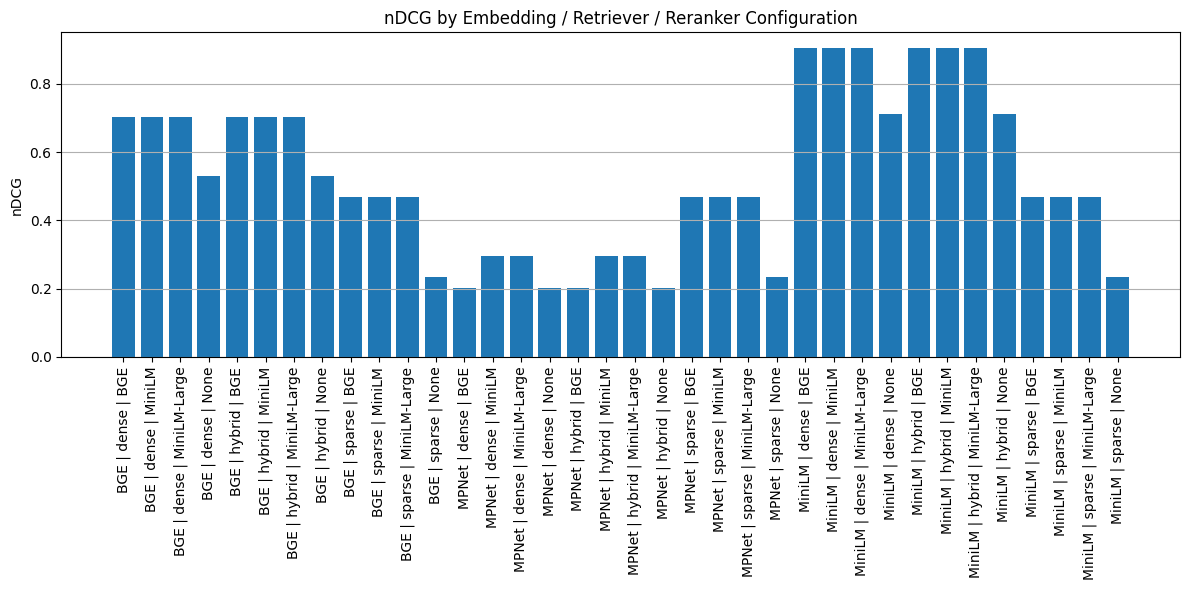

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
agg_df = (
    df
    .groupby(["Embedding", "Retriever", "Reranker"], as_index=False)
    .agg({
        "Recall@K": "mean",
        "MRR": "mean",
        "nDCG": "mean"
    })
)



plt.figure(figsize=(12, 6))

labels = (
    agg_df["Embedding"]
    + " | "
    + agg_df["Retriever"]
    + " | "
    + agg_df["Reranker"]
)

plt.bar(labels, agg_df["nDCG"])
plt.xticks(rotation=90)
plt.ylabel("nDCG")
plt.title("nDCG by Embedding / Retriever / Reranker Configuration")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


In [ ]:
# best_row = (
#     agg_df
#     .sort_values(by=["nDCG", "MRR", "Recall@K"], ascending=False)
#     .iloc[0]
# )


# print("Best Configuration:")
# print(f"Embedding  : {best_row['Embedding']}")
# print(f"Retriever  : {best_row['Retriever']}")
# print(f"Reranker   : {best_row['Reranker']}")
# print(f"Recall@K  : {best_row['Recall@K']:.3f}")
# print(f"MRR       : {best_row['MRR']:.3f}")
# print(f"nDCG      : {best_row['nDCG']:.3f}")

# #save the results
# agg_df.to_csv("rag_experiment_results.csv", index=False)



# Capstone RAG – Conversational RAG (Option B)

This notebook implements **Conversational RAG**, extending the RAG system with:

- Conversation memory (chat history)
- History-aware query rewriting
- Follow-up question handling
- Gemini-powered answer generation

This notebook satisfies **Capstone Requirement #5: Build Conversational RAG**.

In [41]:
# ===== SETUP =====
!pip install -q sentence-transformers rank-bm25 faiss-cpu transformers pypdf google-generativeai

import os
import faiss
import numpy as np
from collections import deque

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import google.generativeai as genai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.2 requires protobuf<5,>=3.20, but you have protobuf 5.29.6 which is incompatible.
google-adk 1.25.1 requires tenacity<10.0.0,>=9.0.0, but you have tenacity 8.5.0 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [42]:

# ===== CONFIG =====
TOP_K = 5
MAX_HISTORY = 5   # number of past turns to keep

GEMINI_MODEL = "models/gemini-2.5-flash"

In [43]:
from google.colab import userdata
import os
import google.generativeai as genai

# Fetch secret from Colab
api_key = userdata.get("GOOGLE_API_KEY")

# Validate
assert api_key is not None, "GOOGLE_API_KEY not found in Colab secrets"

# Set environment variable explicitly
os.environ["GEMINI_API_KEY"] = api_key

# Configure Gemini
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

# Initialize model
GEMINI_MODEL = "models/gemini-2.5-flash"
llm = genai.GenerativeModel(GEMINI_MODEL)


**CG Task 5: Connect your vector database to an LLM and build a RAG pipeline**

In [44]:
# ===== CONVERSATION MEMORY =====
class ConversationMemory:
    def __init__(self, max_turns=MAX_HISTORY):
        self.history = deque(maxlen=max_turns)

    def add_turn(self, user, assistant):
        self.history.append((user, assistant))

    def get_context(self):
        context = ""
        for u, a in self.history:
            context += f"User: {u}\nAssistant: {a}\n"
        return context


# ===== RETRIEVE (FINAL, SINGLE-MODEL) =====
BEST_EMBEDDING = "MPNet"  # choose from experiments

embedding_model = faiss_indexes[BEST_EMBEDDING]["model"]
faiss_index = faiss_indexes[BEST_EMBEDDING]["index"]
docs = chunks  # or documents, depending on your variable name

def retrieve(query, k=TOP_K):
    if faiss_index is None:
        return []

    q_emb = embedding_model.encode([query], normalize_embeddings=True)
    scores, idx = faiss_index.search(q_emb, k)

    results = []
    for rank, i in enumerate(idx[0]):
        results.append({
            "doc": docs[i],
            "score": float(scores[0][rank])
        })
    return results


# ===== ANSWER GENERATION =====
def generate_answer(query, retrieved, memory):
    context = "\n\n".join([r["doc"]["text"] for r in retrieved])

    prompt = f"""
You are a helpful assistant.
Answer the question using ONLY the context below.

Conversation:
{memory.get_context()}

Context:
{context}

Question:
{query}
"""
    response = llm.generate_content(prompt)
    return response.text.strip()

# ===== HISTORY-AWARE QUERY REWRITER =====
def rewrite_query(current_query, memory):
    if not memory.history:
        return current_query

    prompt = f"""
Conversation so far:
{memory.get_context()}

User follow-up question:
{current_query}

Rewrite the follow-up question into a standalone search query.
"""
    response = llm.generate_content(prompt)
    return response.text.strip()



# ===== CONVERSATIONAL RAG PIPELINE =====
def conversational_rag(user_query, memory, top_sources=3):
    standalone_query = rewrite_query(user_query, memory)

    retrieved = retrieve(standalone_query)
    answer = generate_answer(user_query, retrieved, memory)

    memory.add_turn(user_query, answer)

    sources = []
    for r in retrieved[:top_sources]:
        doc = r["doc"]
        sources.append({
            "page": doc.get("page"),
            "chunk_id": doc.get("chunk_id"),
            "score": round(r["score"], 4),
            "preview": doc["text"][:200] + "..."
        })

    return answer, sources


**CG Task 6:	Test the RAG pipeline on sample queries**

**CG Task 7:	Try to also show the source of the generated response (which context documents were used to generate the response - top 3 will do)**

In [45]:

# ===== DEMO (WITH SOURCES) =====
memory = ConversationMemory()

print("Q1: What is self-attention?")
answer, sources = conversational_rag("What is self-attention?", memory)
print("Answer:\n", answer)
print("\nSources:")
for s in sources:
    print(f"- Page {s['page']}, Chunk {s['chunk_id']} (score={s['score']})")

print("\nQ2: Why is it better than RNNs?")
answer, sources = conversational_rag("Why is it better than RNNs?", memory)
print("Answer:\n", answer)
print("\nSources:")
for s in sources:
    print(f"- Page {s['page']}, Chunk {s['chunk_id']} (score={s['score']})")


Q1: What is self-attention?
Answer:
 Self-attention layers are compared to recurrent and convolutional layers, which are commonly used for mapping one variable-length sequence of symbol representations (x1,..., xn) to another sequence of equal length (z1,..., zn), with xi, zi ∈ rd, such as a hidden layer in a typical sequence transduction encoder or decoder. It was also proposed to replace RNNs.

Sources:
- Page 13, Chunk 0 (score=0.3876)
- Page 15, Chunk 0 (score=0.305)
- Page 6, Chunk 2 (score=0.3018)

Q2: Why is it better than RNNs?
Answer:
 Self-attention layers are faster than recurrent layers in terms of computational complexity when the sequence length allows. A self-attention layer connects all positions with a constant number of sequentially executed operations, whereas a recurrent layer requires o(n) sequential operations. The shorter path length between any two input and output positions in self-attention layers makes it easier to learn long-range dependencies. Additionally,

In [46]:
import faiss
import pickle

# Save FAISS index
faiss.write_index(faiss_index, "faiss_index.bin")

# Save chunks
with open("chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print("Knowledge Base artifacts saved")


Knowledge Base artifacts saved


In [ ]:
# Load chunks
with open("chunks.pkl", "rb") as f:
    chunks = pickle.load(f)

texts = [c["text"] for c in chunks]

# Embed
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = model.encode(texts, normalize_embeddings=True)

# Build FAISS
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

print("FAISS vectors:", index.ntotal)

faiss.write_index(index, "/content/faiss_index.bin")


FAISS vectors: 108


In [ ]:
!ls -lh faiss_index.bin chunks.pkl


-rw-r--r-- 1 root root  97K Dec 21 15:08 chunks.pkl
-rw-r--r-- 1 root root 163K Dec 21 15:58 faiss_index.bin


In [ ]:
with open("chunks.pkl", "rb") as f:
    test = pickle.load(f)

print(type(test), len(test))
print(test[0].keys())


<class 'list'> 108
dict_keys(['text', 'page', 'chunk_id'])


In [ ]:
# import pickle

# with open("chunks.pkl", "rb") as f:
#     obj = pickle.load(f)

# print("Loaded object type:", type(obj))
# print("Loaded object value:", obj)


Loaded object type: <class 'NoneType'>
Loaded object value: None


In [ ]:

with open("chunks.pkl", "rb") as f:
    chunks = pickle.load(f)

print("Total chunks:", len(chunks))
print("Invalid chunks:", sum(1 for c in chunks if not c or not c.get("text")))


Total chunks: 108
Invalid chunks: 0


In [ ]:
from google.colab import userdata
import os

os.environ["GEMINI_API_KEY"] = userdata.get("GOOGLE_API_KEY")
print("GEMINI_API_KEY exported to environment")



GEMINI_API_KEY exported to environment


In [ ]:
!pip install duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 42.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
# =========================================================
# AGENTIC CONVERSATIONAL RAG — FINAL STREAMLIT APP
# =========================================================

# ---------- MUST BE FIRST STREAMLIT CALL ----------
import streamlit as st
st.set_page_config(page_title="Agentic Conversational RAG", layout="wide")

# =========================================================
# ENV + NOISE SUPPRESSION
# =========================================================
import os, warnings, time, uuid
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
warnings.filterwarnings("ignore")

# =========================================================
# IMPORTS
# =========================================================
import faiss
import pickle
import google.generativeai as genai
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from collections import deque
from duckduckgo_search import DDGS
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
FAISS_PATH = "/content/faiss_index.bin"
CHUNKS_PATH = "/content/chunks.pkl"

TOP_K = 5
MAX_HISTORY = 5
GEMINI_MODEL = "models/gemini-2.5-flash"

FINAL_CONFIG = {
    "embedding": "sentence-transformers/all-MiniLM-L6-v2",
    "reranker": "cross-encoder/ms-marco-MiniLM-L-6-v2"
}

# Approx cost units (relative, for analysis)
COST_TABLE = {
    "kb": 1.0,
    "web": 2.5,
    "judge": 0.5
}

# =========================================================
# SESSION STATE INIT
# =========================================================
for k in [
    "kb_loaded", "faiss_index", "chunks", "bm25",
    "agents", "cost_log"
]:
    if k not in st.session_state:
        st.session_state[k] = {} if k == "agents" else False if k == "kb_loaded" else []

# =========================================================
# GEMINI SETUP
# =========================================================
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    st.error("GEMINI_API_KEY not found.")
    st.stop()

genai.configure(api_key=api_key)
llm = genai.GenerativeModel(GEMINI_MODEL)

# =========================================================
# LOAD MODELS
# =========================================================
@st.cache_resource
def load_models():
    return (
        SentenceTransformer(FINAL_CONFIG["embedding"]),
        CrossEncoder(FINAL_CONFIG["reranker"])
    )

embedding_model, reranker = load_models()

# =========================================================
# LOAD KNOWLEDGE BASE
# =========================================================
@st.cache_resource
def load_knowledge_base():
    if not os.path.exists(FAISS_PATH) or not os.path.exists(CHUNKS_PATH):
        return None, None, None

    index = faiss.read_index(FAISS_PATH)

    with open(CHUNKS_PATH, "rb") as f:
        chunks = pickle.load(f)

    if not isinstance(chunks, list):
        return None, None, None

    valid_chunks = [
        c for c in chunks
        if isinstance(c, dict) and isinstance(c.get("text"), str) and c["text"].strip()
    ]

    if not valid_chunks:
        return None, None, None

    bm25 = BM25Okapi([c["text"].split() for c in valid_chunks])
    return index, valid_chunks, bm25

# =========================================================
# MEMORY
# =========================================================
class ConversationMemory:
    def __init__(self):
        self.history = deque(maxlen=MAX_HISTORY)

    def add(self, u, a):
        self.history.append((u, a))

    def context(self):
        return "\n".join(f"User: {u}\nAssistant: {a}" for u, a in self.history)

# =========================================================
# RETRIEVAL
# =========================================================
def dense_retrieve(query):
    index = st.session_state.faiss_index
    chunks = st.session_state.chunks
    if index is None or not chunks:
        return []

    emb = embedding_model.encode([query], normalize_embeddings=True)
    _, idx = index.search(emb, min(TOP_K * 2, index.ntotal))
    return [chunks[i] for i in idx[0] if i < len(chunks)]

def sparse_retrieve(query):
    bm25 = st.session_state.bm25
    chunks = st.session_state.chunks
    if bm25 is None:
        return []

    scores = bm25.get_scores(query.split())
    idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:TOP_K * 2]
    return [chunks[i] for i in idx]

def hybrid_retrieve(query):
    seen = {}
    for d in dense_retrieve(query) + sparse_retrieve(query):
        seen[id(d)] = d
    return list(seen.values())[:TOP_K]

# =========================================================
# WEB SEARCH (CORRECTIVE)
# =========================================================
def web_search(query):
    docs = []
    with DDGS() as ddgs:
        for r in ddgs.text(query, max_results=5):
            docs.append({"text": r.get("body", ""), "page": "web"})
    return docs

def retrieval_confident(docs):
    return len(docs) >= 2 and sum(len(d["text"]) for d in docs) / len(docs) > 60


def llm_relevance_check(question, docs):
    """
    Ask the LLM whether the retrieved context can actually answer the question.
    """
    context = "\n\n".join(d["text"] for d in docs[:3])

    prompt = f"""
Question:
{question}

Context:
{context}

Does the context contain enough information to answer the question?
Reply ONLY with one word: YES or NO.
"""

    try:
        resp = llm.generate_content(prompt).text.strip().upper()
        return resp.startswith("YES")
    except Exception:
        return False

# =========================================================
# AGENTIC RETRIEVAL
# =========================================================
def agent_retrieve(query, trace):
    kb_docs = hybrid_retrieve(query)

    # --- Gate 1: Structural confidence ---
    if retrieval_confident(kb_docs):
        # --- Gate 2: Semantic confidence ---
        if llm_relevance_check(query, kb_docs):
            trace["source"] = "kb"
            return kb_docs

    # --- Corrective escalation ---
    web_docs = web_search(query)
    trace["source"] = "web"
    trace["used_web"] = True

    return kb_docs + web_docs

# =========================================================
# RERANK + ANSWER
# =========================================================
def rerank(query, docs):
    pairs = [(query, d["text"]) for d in docs]
    scores = reranker.predict(pairs)
    return [d for d, _ in sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)]

def generate_answer(query, docs, memory):
    context = "\n\n".join(d["text"] for d in docs)
    prompt = f"""
Conversation:
{memory.context()}

Context:
{context}

Question:
{query}

Answer only from context.
"""
    return llm.generate_content(prompt).text.strip()

# =========================================================
# LLM AS JUDGE
# =========================================================
def judge_answer(q, a, docs):
    ctx = "\n".join(d["text"] for d in docs)
    prompt = f"""
Question: {q}
Answer: {a}
Context: {ctx}

Return JSON:
{{"faithfulness": float, "hallucinated": true/false}}
"""
    return llm.generate_content(prompt).text

# =========================================================
# COST TRACKING
# =========================================================
def log_cost(user, source):
    st.session_state.cost_log.append({
        "user": user,
        "cost": COST_TABLE[source]
    })

# =========================================================
# UI
# =========================================================
st.title("Agentic Conversational RAG — Final")

# ----- LOAD KB -----
if st.button("Load Knowledge Base"):
    with st.spinner("Loading KB..."):
        idx, ch, bm = load_knowledge_base()
        if idx:
            st.session_state.faiss_index = idx
            st.session_state.chunks = ch
            st.session_state.bm25 = bm
            st.session_state.kb_loaded = True
            st.success("KB Loaded")

st.info("KB Loaded" if st.session_state.kb_loaded else "KB Not Loaded")

# ----- USER -----
user_id = st.text_input("User ID", value=str(uuid.uuid4()))
if user_id not in st.session_state.agents:
    st.session_state.agents[user_id] = ConversationMemory()

memory = st.session_state.agents[user_id]

# ----- QUERY -----
query = st.text_input("Ask a question")

if st.button("Submit"):
    if not st.session_state.kb_loaded:
        st.warning("Load KB first.")
        st.stop()

    trace = {}
    with st.spinner("Thinking..."):
        docs = agent_retrieve(query, trace)
        ranked = rerank(query, docs)
        answer = generate_answer(query, ranked, memory)
        memory.add(query, answer)
        judge = judge_answer(query, answer, ranked)

        log_cost(user_id, trace["source"])
        log_cost(user_id, "judge")

    st.subheader("Answer")
    st.write(answer)

    with st.expander("Sources"):
        for d in ranked[:3]:
            st.write(d.get("page", "kb"))

    with st.expander("LLM-as-Judge"):
        st.code(judge, language="json")

    with st.expander("Agent Trace"):
        st.json(trace)

# =========================================================
# COST VS QUALITY
# =========================================================
st.header("Cost vs Quality Analysis")

if st.session_state.cost_log:
    users = [c["user"] for c in st.session_state.cost_log]
    costs = [c["cost"] for c in st.session_state.cost_log]

    fig, ax = plt.subplots()
    ax.bar(users, costs)
    ax.set_ylabel("Cost Units")
    ax.set_title("Per-Agent Cost")
    st.pyplot(fig)

    st.success("Cheapest viable config: Hybrid KB + MiniLM reranker")



Overwriting app.py


In [ ]:
ngrok.kill()
!pkill -f streamlit

!ps -ef | grep streamlit

root      169960       1  9 17:00 ?        00:00:30 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 8502 --server.address 0.0.0.0
root      171297  132317  0 17:05 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root      171299  171297  0 17:05 ?        00:00:00 grep streamlit


In [ ]:
!streamlit run app.py \
  --server.port 8502 \
  --server.address 0.0.0.0 \
  &> logs.txt &

import time
time.sleep(5)

from google.colab import userdata
from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()
with open("chunks.pkl", "rb") as f:
    test = pickle.load(f)

print(type(test), len(test))
print(test[0].keys())

# Fetch ngrok token from Colab secrets
ngrok_token = userdata.get("NGORK_AUTH_TOKEN")
assert ngrok_token is not None, "NGORK_AUTH_TOKEN not found in Colab secrets"

# Set token
ngrok.set_auth_token(ngrok_token)

# Open tunnel to SAME port as Streamlit
ngrok_tunnel = ngrok.connect(8502)

print("Streamlit App:", ngrok_tunnel.public_url)


<class 'list'> 108
dict_keys(['text', 'page', 'chunk_id'])
Streamlit App: https://f0e38ddf71c8.ngrok-free.app


In [ ]:
!curl http://localhost:8502

<!doctype html><html lang="en"><head><meta charset="UTF-8"/><meta name="viewport" content="width=device-width,initial-scale=1,shrink-to-fit=no"/><link rel="shortcut icon" href="./favicon.png"/><link rel="preload" href="./static/media/SourceSansPro-Regular.0d69e5ff5e92ac64a0c9.woff2" as="font" type="font/woff2" crossorigin><link rel="preload" href="./static/media/SourceSansPro-SemiBold.abed79cd0df1827e18cf.woff2" as="font" type="font/woff2" crossorigin><link rel="preload" href="./static/media/SourceSansPro-Bold.118dea98980e20a81ced.woff2" as="font" type="font/woff2" crossorigin><title>Streamlit</title><script>window.prerenderReady=!1</script><script defer="defer" src="./static/js/main.d0867666.js"></script><link href="./static/css/main.77d1c464.css" rel="stylesheet"></head><body><noscript>You need to enable JavaScript to run this app.</noscript><div id="root"></div></body></html>

In [ ]:
!cat logs.txt




  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8502

E0000 00:00:1766335878.407103  167731 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766335878.416974  167731 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766335878.439464  167731 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766335878.439529  167731 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766335878.439533  167731 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766335878.439536  1677